In [2]:
import numpy as np

In [3]:
X = np.array([
    [0,0,0,0],
    [0,0,1,1],
    [1,1,0,0],
    [1,1,1,1]
], dtype=np.float32)
print(X)

[[0. 0. 0. 0.]
 [0. 0. 1. 1.]
 [1. 1. 0. 0.]
 [1. 1. 1. 1.]]


![encoder-to-decoder](encoder-to-decoder.png)

In [17]:
input_size = 4
hidden_size = 2

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, input_size) * 0.1
b2 = np.zeros((1, input_size))

In [18]:
W1, b1, W2, b2

(array([[-0.0510544 ,  0.23209709],
        [ 0.07894636, -0.0885824 ],
        [ 0.06144982,  0.03677052],
        [-0.10520009,  0.16802503]]),
 array([[0., 0.]]),
 array([[ 0.09886906, -0.00349845, -0.01592682, -0.01453798],
        [-0.0719014 , -0.19058643,  0.02041662,  0.09072092]]),
 array([[0., 0., 0., 0.]]))

In [19]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [20]:
#Encoder
hidden = sigmoid(X@W1 + b1)
#Decoder
output = sigmoid(hidden@W2 + b2)
output

array([[0.50337091, 0.47575841, 0.50056123, 0.50952172],
       [0.50218353, 0.47334329, 0.50086519, 0.51071813],
       [0.50289944, 0.47405006, 0.50071628, 0.51030841],
       [0.50172334, 0.47166574, 0.50101703, 0.51149046]])

In [ ]:
# Computing the loss (mse)
loss = np.mean((X-output)**2)
print("Loss:", loss)

Loss: 0.2502864241421011


In [ ]:
# Backpropagation
output_error = X - output
output_delta = output_error * sigmoid_derivative(output)
hidden_error = output_delta @ W2.T
hidden_delta = hidden_error * sigmoid_derivative(hidden)

In [25]:
print("Output Error:\n", output_error)
print("Output Delta:\n", output_delta)
print("Hidden Error:\n", hidden_error)
print("Hidden Delta:\n", hidden_delta)

Output Error:
 [[-0.50337091 -0.47575841 -0.50056123 -0.50952172]
 [-0.50218353 -0.47334329  0.49913481  0.48928187]
 [ 0.49710056  0.52594994 -0.50071628 -0.51030841]
 [ 0.49827666  0.52833426  0.49898297  0.48850954]]
Output Delta:
 [[-0.12583701 -0.11866002 -0.12514015 -0.12733423]
 [-0.12554349 -0.11799947  0.12478333  0.12226426]
 [ 0.12427096  0.13113331 -0.12517881 -0.12752287]
 [ 0.12456768  0.1316594   0.12474523  0.12206289]]
Hidden Error:
 [[-0.00818199  0.01755603]
 [-0.01576443  0.04515543]
 [ 0.01567542 -0.04805221]
 [ 0.00809394 -0.02042855]]
Hidden Delta:
 [[-0.0020455   0.00438901]
 [-0.00393922  0.01117131]
 [ 0.00391809 -0.01195141]
 [ 0.00202336 -0.00495532]]


In [26]:
learning_rate = 0.1

W2 += hidden.T @ output_delta * learning_rate
b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate

W1 += X.T @ hidden_delta * learning_rate
b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate

In [ ]:
losses = []

for epoch in range(5000):
    
    #forward pass is going here
    hidden = sigmoid(X @ W1 + b1)
    output = sigmoid(hidden @ W2 + b2)
    
    #loss is getting computed here
    loss = np.mean((X - output) ** 2)
    #added to the list of losses for plotting later
    losses.append(loss)
    
    #backpropagation
    output_error = X - output
    output_delta = output_error * sigmoid_derivative(output)
    hidden_error = output_delta @ W2.T
    hidden_delta = hidden_error * sigmoid_derivative(hidden)
    
    #Update
    W2 += hidden.T @ output_delta * learning_rate
    b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate
    W1 += X.T @ hidden_delta * learning_rate
    b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate
    
    if epoch % 500 == 0:
        print(epoch, loss)

0 0.25025421824213123
500 0.10026781654999688
1000 0.01879449027439343
1500 0.008697735057987297
2000 0.005515779981673432
2500 0.004002309658321324
3000 0.003126814832960647
3500 0.0025591122065325806
4000 0.002162385142730004
4500 0.0018700926160069712


predict
→ measure mistakes
→ send blame backward
→ adjust weights
→ improve predictions

In [ ]:
losses = []

for epoch in range(5000):
    hidden = sigmoid(X @ W1 + b1)
    output = sigmoid(hidden @ W2 + b2)
    loss = np.mean((X - output) ** 2)
    losses.append(loss)
    output_error = X - output
    output_delta = output_error * sigmoid_derivative(output)
    hidden_error = output_delta @ W2.T
    hidden_delta = hidden_error * sigmoid_derivative(hidden)
    W2 += hidden.T @ output_delta * learning_rate
    b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate
    W1 += X.T @ hidden_delta * learning_rate
    b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate
    if epoch % 500 == 0:
        print(epoch, loss)

0 0.00164610765162763
500 0.001469171184912839
1000 0.0013259785596516948
1500 0.0012077878972780775
2000 0.001108624052493224
2500 0.0010242673559917033
3000 0.000951654816874817
3500 0.000888510295519178
4000 0.0008331077678717
4500 0.0007841150447915501


Text(0.5, 1.0, 'Training Loss')

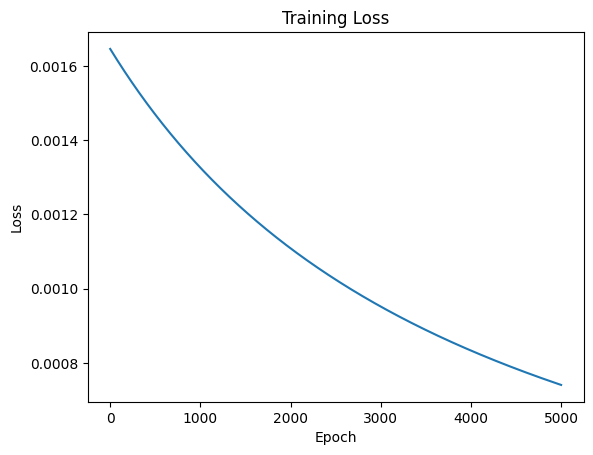

In [31]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

In [32]:
print("Original:")
print(X)
print("\nReconstructed:")
print(np.round(output, 2))

Original:
[[0. 0. 0. 0.]
 [0. 0. 1. 1.]
 [1. 1. 0. 0.]
 [1. 1. 1. 1.]]

Reconstructed:
[[0.03 0.03 0.03 0.03]
 [0.03 0.03 0.98 0.98]
 [0.98 0.98 0.03 0.03]
 [0.97 0.97 0.97 0.97]]
